# ==========================================================
# Ethiopia Exchange Rate & Inflation Analysis (Auto-download)
# ==========================================================

In [5]:
# installing important packages
# !pip install requests
# !pip install pandas
# !pip install matplotlib

In [6]:
# ----------------------------
#  Import Libraries
# ----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import requests

### 💱 Fetching ETB/USD Exchange Rates

This script retrieves historical annual exchange rate data for the **Ethiopian Birr (ETB)** against the **US Dollar (USD)** using the [World Bank Open Data API](https://data.worldbank.org/).

#### API Configuration
- **Indicator**: `PA.NUS.FCRF` (Official exchange rate, LCU per US$, period average).
- **Endpoint**: Ethiopia (`ETH`) specific time-series.
- **Format**: JSON (returning the 100 most recent records).

#### Data Access
The response is returned as a nested list:
* `data_rate[0]`: Contains API metadata and pagination.
* `data_rate[1]`: Contains the actual observation list (Year and Rate).

In [28]:
# Countries and codes
countries = {
    "Ethiopia": "ETH",
    "Kenya": "KEN",
    "Japan": "JPN",
    "Brazil": "BRA",
    "India": "IND"
}

indicator = "PA.NUS.FCRF"
indicator_inf = "FP.CPI.TOTL.ZG"

all_exchange_rate_data = []
all_inflation_data = []

for country, code in countries.items():
    
    url = f"https://api.worldbank.org/v2/country/{code}/indicator/{indicator}?format=json&per_page=1000"
    url_inf = f"https://api.worldbank.org/v2/country/{code}/indicator/{indicator_inf}?format=json&per_page=100"
    
    
    response = requests.get(url)
    response_inf = requests.get(url_inf)

    data = response.json()
    data_inf = response_inf.json()
    
    records = data[1]
    records_inf = data_inf[1]

    for item in records:
        all_exchange_rate_data.append({
            "Country": country,
            "Year": item["date"],
            "Exchange Rate": item["value"]
        })
    for item in records_inf:
        all_inflation_data.append({
            "Country": country,
            "Year": item["date"],
            "Inflation Rate": item["value"]
        })
# Convert to DataFrame
df = pd.DataFrame(all_exchange_rate_data)
df_inf = pd.DataFrame(all_inflation_data)

# Remove missing values
df = df.dropna()
df_inf = df_inf.dropna()

# Sort
df = df.sort_values(["Country", "Year"])
df_inf = df_inf.sort_values(["Country", "Year"])

print(df.head())

# Save to CSV
df.to_csv("world_exchange_rates.csv", index=False)
df_inf.to_csv("world_inflation_rates.csv", index=False)

print("CSV saved successfully")

    Country  Year  Exchange Rate
263  Brazil  1960   8.099705e-14
262  Brazil  1961   1.168435e-13
261  Brazil  1962   1.677642e-13
260  Brazil  1963   2.488694e-13
259  Brazil  1964   5.420239e-13
CSV saved successfully


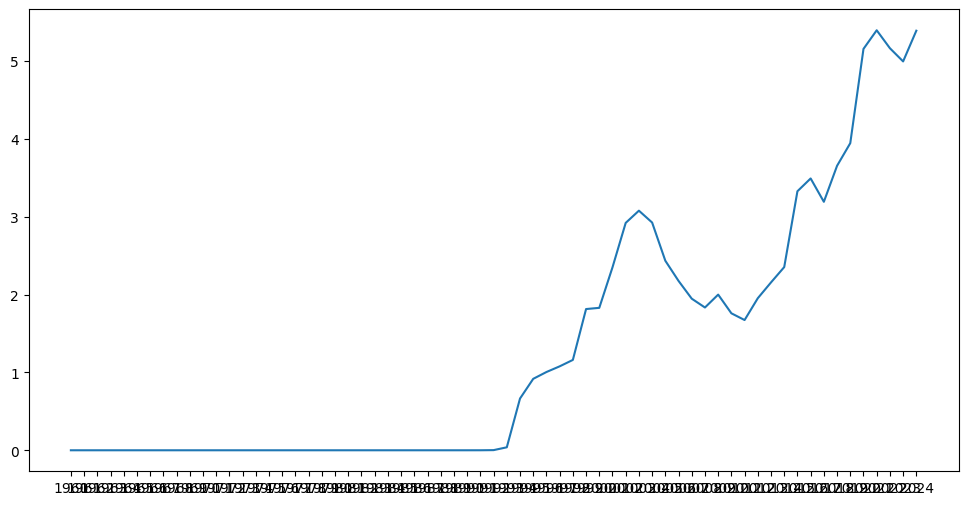

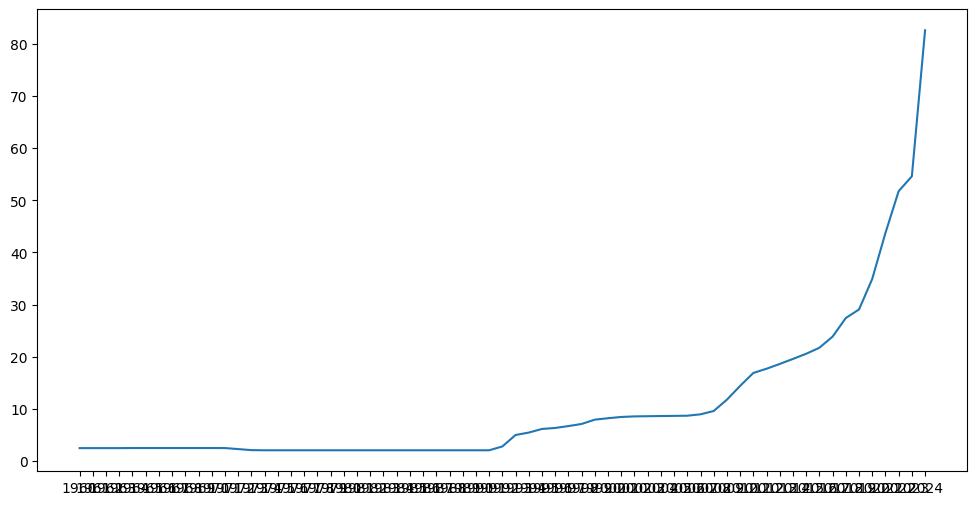

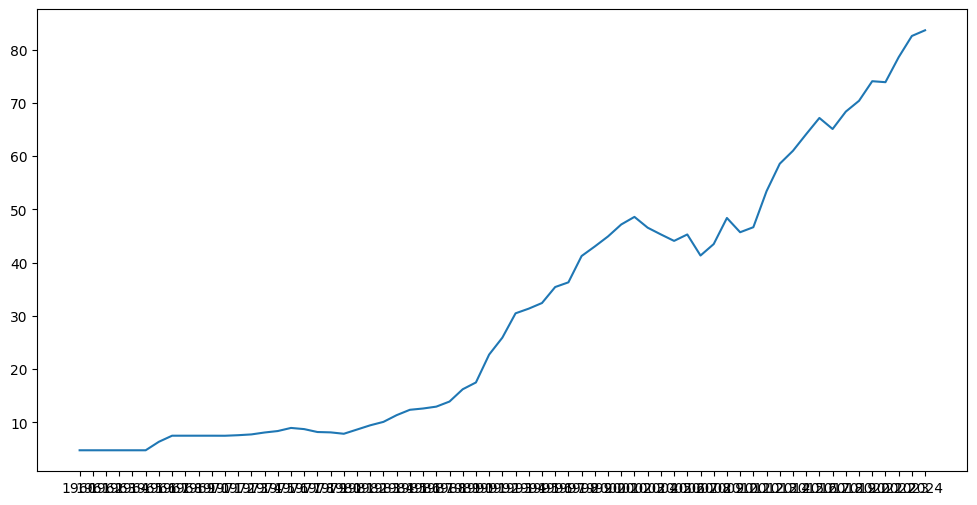

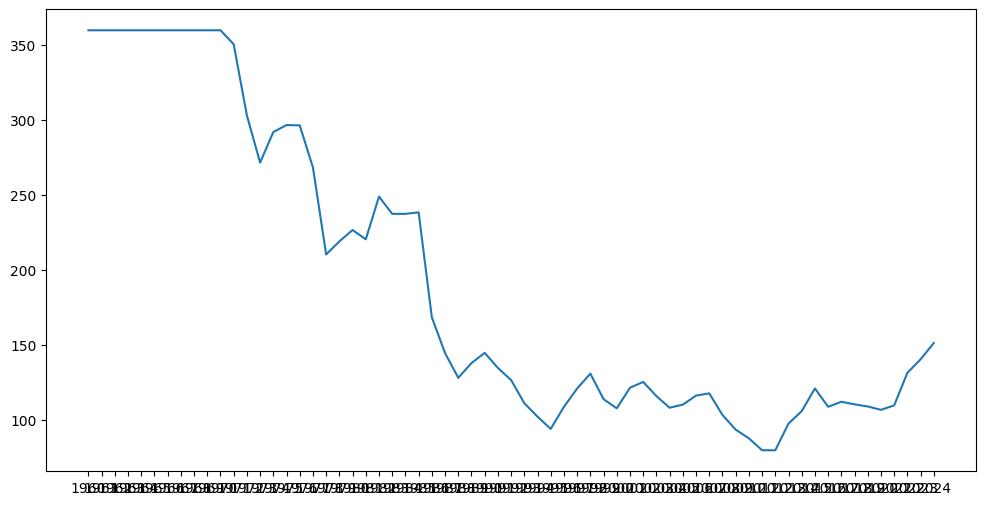

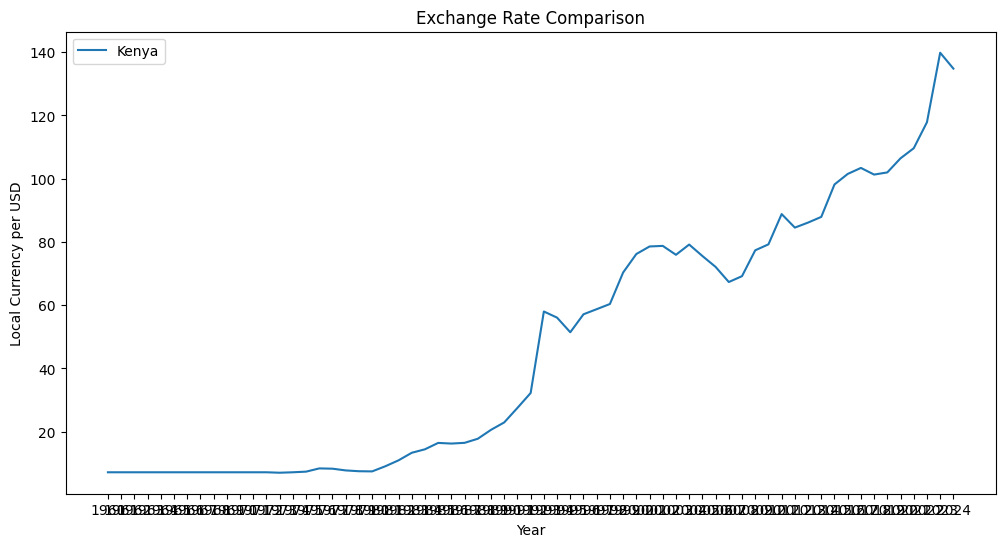

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    
    plt.plot(subset["Year"], subset["Exchange Rate"], label=country)


plt.legend()
plt.title("Exchange Rate Comparison")
plt.xlabel("Year")
plt.ylabel("Local Currency per USD")
plt.show()

In [15]:
# ----------------------------
# Download Exchange Rate Data (ETB/USD)
# ----------------------------
url_rate = "https://api.worldbank.org/v2/country/ETH/indicator/PA.NUS.FCRF?format=json&per_page=100"
response_rate = requests.get(url_rate)
data_rate = response_rate.json()
print(data_rate[1])  # Check the structure of the response



[{'indicator': {'id': 'PA.NUS.FCRF', 'value': 'Official exchange rate (LCU per US$, period average)'}, 'country': {'id': 'ET', 'value': 'Ethiopia'}, 'countryiso3code': 'ETH', 'date': '2025', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 2}, {'indicator': {'id': 'PA.NUS.FCRF', 'value': 'Official exchange rate (LCU per US$, period average)'}, 'country': {'id': 'ET', 'value': 'Ethiopia'}, 'countryiso3code': 'ETH', 'date': '2024', 'value': 82.6013363504764, 'unit': '', 'obs_status': '', 'decimal': 2}, {'indicator': {'id': 'PA.NUS.FCRF', 'value': 'Official exchange rate (LCU per US$, period average)'}, 'country': {'id': 'ET', 'value': 'Ethiopia'}, 'countryiso3code': 'ETH', 'date': '2023', 'value': 54.6009480676569, 'unit': '', 'obs_status': '', 'decimal': 2}, {'indicator': {'id': 'PA.NUS.FCRF', 'value': 'Official exchange rate (LCU per US$, period average)'}, 'country': {'id': 'ET', 'value': 'Ethiopia'}, 'countryiso3code': 'ETH', 'date': '2022', 'value': 51.7562150334169, 'unit': 

### 📊 Data Processing & Cleaning

This step transforms the raw API response into a structured **Pandas DataFrame** for analysis.

#### Processing Steps:
1.  **Extraction**: Isolates the records from the nested JSON structure.
2.  **Selection & Renaming**: Extracts only the `date` and `value` fields and renames them to `Year` and `Exchange_Rate`.
3.  **Cleaning**: Removes any null records (`dropna`) to ensure data integrity.
4.  **Formatting**: Converts the `Year` column to an integer type for better handling during plotting or filtering.
5.  **Ordering**: Sorts the data chronologically (oldest to newest) to prepare for time-series visualization.

In [21]:
# Extract records
records_rate = data_rate[1]
df_rate_raw = pd.DataFrame(records_rate)[["date", "value"]]
df_rate_raw.columns = ["Year", "Exchange_Rate"]
df_rate_raw = df_rate_raw.dropna()
df_rate_raw["Year"] = df_rate_raw["Year"].astype(int)
df_rate_raw = df_rate_raw.sort_values("Year")

print("Exchange Rate Data Loaded ✅")
print(df_rate_raw.head())

# Save to CSV
df_rate_raw.to_csv("usd_etb_exchange_rate.csv")
print("Exchange rate File saved successfully")

Exchange Rate Data Loaded ✅
    Year  Exchange_Rate
65  1960        2.48447
64  1961        2.48447
63  1962        2.48447
62  1963        2.48447
61  1964        2.50000
Exchange rate File saved successfully


In [9]:
# ----------------------------
# 3. Download Inflation Data (Annual %)
# ----------------------------
url_inf = "https://api.worldbank.org/v2/country/ETH/indicator/FP.CPI.TOTL.ZG?format=json&per_page=100"
response_inf = requests.get(url_inf)
data_inf = response_inf.json()

In [22]:
# Extract records
records_inf = data_inf[1]
df_inf_raw = pd.DataFrame(records_inf)[["date", "value"]]
df_inf_raw.columns = ["Year", "Inflation"]
df_inf_raw = df_inf_raw.dropna()
df_inf_raw["Year"] = df_inf_raw["Year"].astype(int)
df_inf_raw = df_inf_raw.sort_values("Year")

print("Inflation Data Loaded ✅")
print(df_inf_raw.head())

# Save to CSV
df_inf_raw.to_csv("usd_etb_inflation.csv")
print("Inflation data File saved successfully")

Inflation Data Loaded ✅
    Year  Inflation
59  1966  -1.361868
58  1967   0.808679
57  1968   0.182613
56  1969   1.425688
55  1970  10.121951
Inflation data File saved successfully


In [23]:
# ----------------------------
# 4. Merge Datasets
# ----------------------------
df_rate = pd.read_csv("usd_etb_exchange_rate.csv")
df_inf = pd.read_csv("usd_etb_exchange_rate.csv")

df = pd.merge(df_rate, df_inf, on="Year", how="inner")
print("Datasets Merged ✅")
print(df.head())

Datasets Merged ✅
   Unnamed: 0_x  Year  Exchange_Rate_x  Unnamed: 0_y  Exchange_Rate_y
0            65  1960          2.48447            65          2.48447
1            64  1961          2.48447            64          2.48447
2            63  1962          2.48447            63          2.48447
3            62  1963          2.48447            62          2.48447
4            61  1964          2.50000            61          2.50000
